In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [3]:
from data_science.plots import plot_confusion_matrix
from data_science.styles import apply_luna_style


In [4]:
apply_luna_style()

## Data


In [5]:
data = pd.read_csv(
    './../../data/wheat-seeds.csv',
    names=[
        'area',
        'perimeter',
        'compactness',
        'length of kernel',
        'width of kernel',
        'asymmetry coefficient',
        'length of groove',
        'type',
    ],
    header=None,
)

In [6]:
label_map = {1: 'Kama', 2: 'Rosa', 3: 'Canadian'}
data['type'] = data['type'].map(label_map)

## Prepare Data


In [7]:
RANDOM_STATE = 42
np.random.default_rng(RANDOM_STATE)

Generator(PCG64) at 0x11731F140

In [8]:
X = data.drop(columns=['type'])
y = data['type']

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

## Decision Tree Classifier


### Model with default parameters


In [11]:
dt_default = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_default.fit(X_train, y_train)
dt_default.score(X_test, y_test)

0.8333333333333334

In [12]:
y_pred_default = dt_default.predict(X_test)

In [13]:
print('Default Decision Tree Classifier')
accuracy = accuracy_score(y_test, y_pred_default)
print(f'Accuracy: {accuracy * 100:.2f}%')
precision = precision_score(y_test, y_pred_default, average='weighted')
print(f'Precision: {precision * 100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_default))

Default Decision Tree Classifier
Accuracy: 83.33%
Precision: 85.59%

Classification Report:
              precision    recall  f1-score   support

    Canadian       0.88      0.82      0.85        17
        Kama       0.64      0.82      0.72        11
        Rosa       1.00      0.86      0.92        14

    accuracy                           0.83        42
   macro avg       0.84      0.83      0.83        42
weighted avg       0.86      0.83      0.84        42



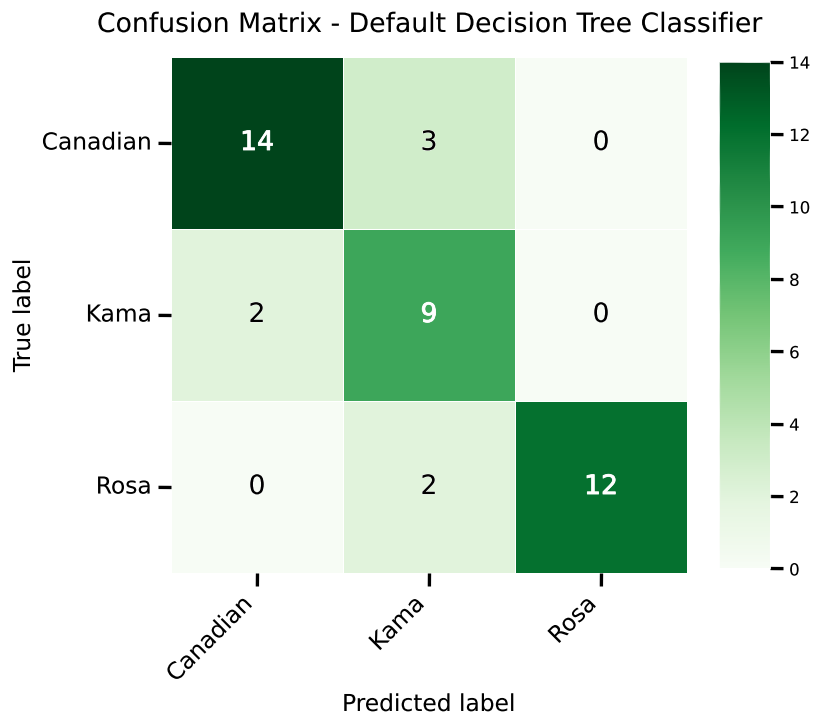

In [14]:
cm_default = confusion_matrix(y_test, y_pred_default)
default_classes = np.unique(np.r_[y_test, y_pred_default])
plot_confusion_matrix(
    cm_default,
    default_classes,
    title='Confusion Matrix - Default Decision Tree Classifier',
)

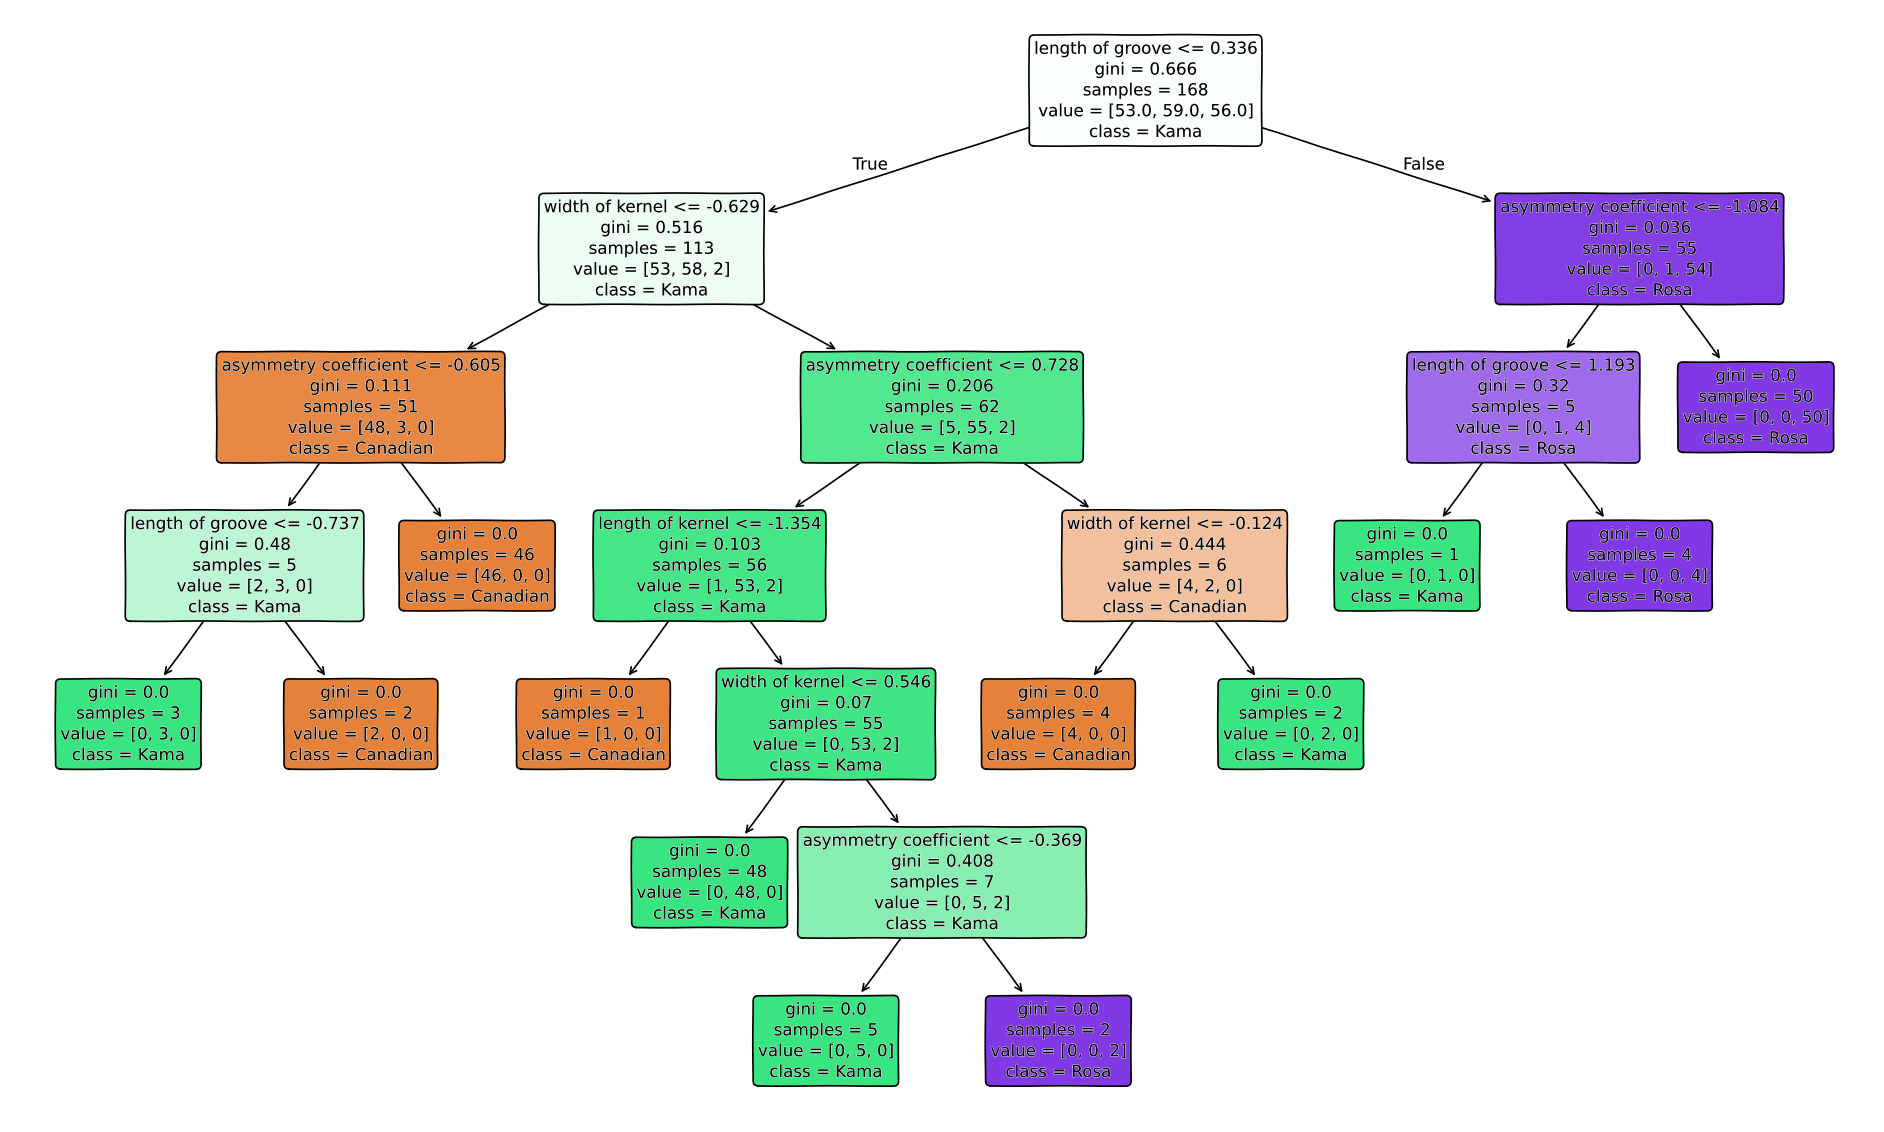

In [15]:
plt.figure(figsize=(20, 12), dpi=120)
plot_tree(
    dt_default,
    feature_names=X.columns,
    class_names=np.unique(y).tolist(),
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.show()

### Model with custom parameters


In [16]:
dt_custom = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
)
dt_custom.fit(X_train, y_train)
dt_custom.score(X_test, y_test)

0.9285714285714286

In [17]:
y_pred_custom = dt_custom.predict(X_test)

In [18]:
print('Custom Decision Tree Classifier')
accuracy = accuracy_score(y_test, y_pred_custom)
print(f'Accuracy: {accuracy * 100:.2f}%')
precision = precision_score(y_test, y_pred_custom, average='weighted')
print(f'Precision: {precision * 100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_custom))

Custom Decision Tree Classifier
Accuracy: 92.86%
Precision: 93.11%

Classification Report:
              precision    recall  f1-score   support

    Canadian       0.94      0.88      0.91        17
        Kama       0.83      0.91      0.87        11
        Rosa       1.00      1.00      1.00        14

    accuracy                           0.93        42
   macro avg       0.92      0.93      0.93        42
weighted avg       0.93      0.93      0.93        42



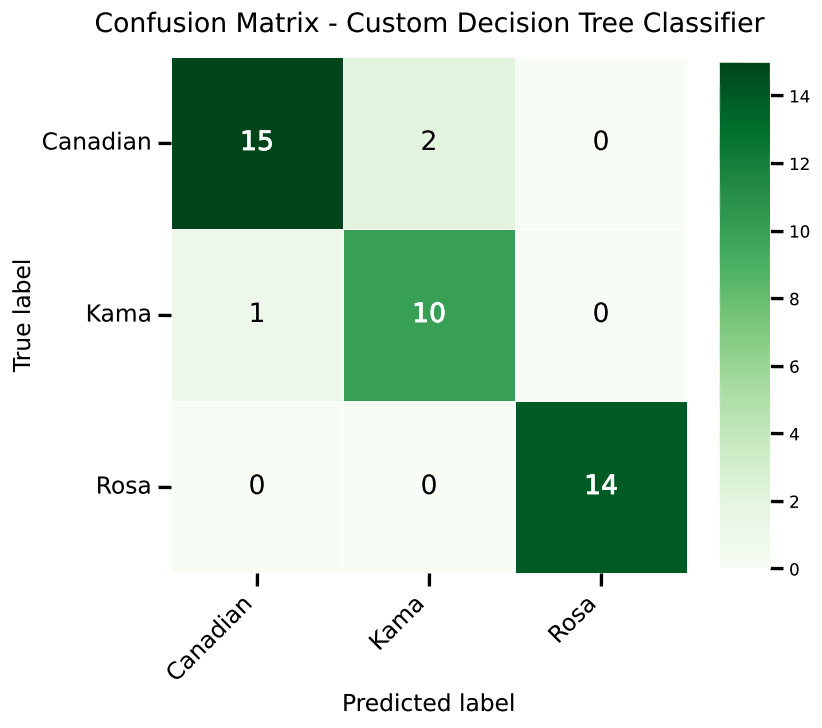

In [19]:
cm_custom = confusion_matrix(y_test, y_pred_custom)
custom_classes = np.unique(np.r_[y_test, y_pred_custom])
plot_confusion_matrix(
    cm_custom,
    custom_classes,
    title='Confusion Matrix - Custom Decision Tree Classifier',
)

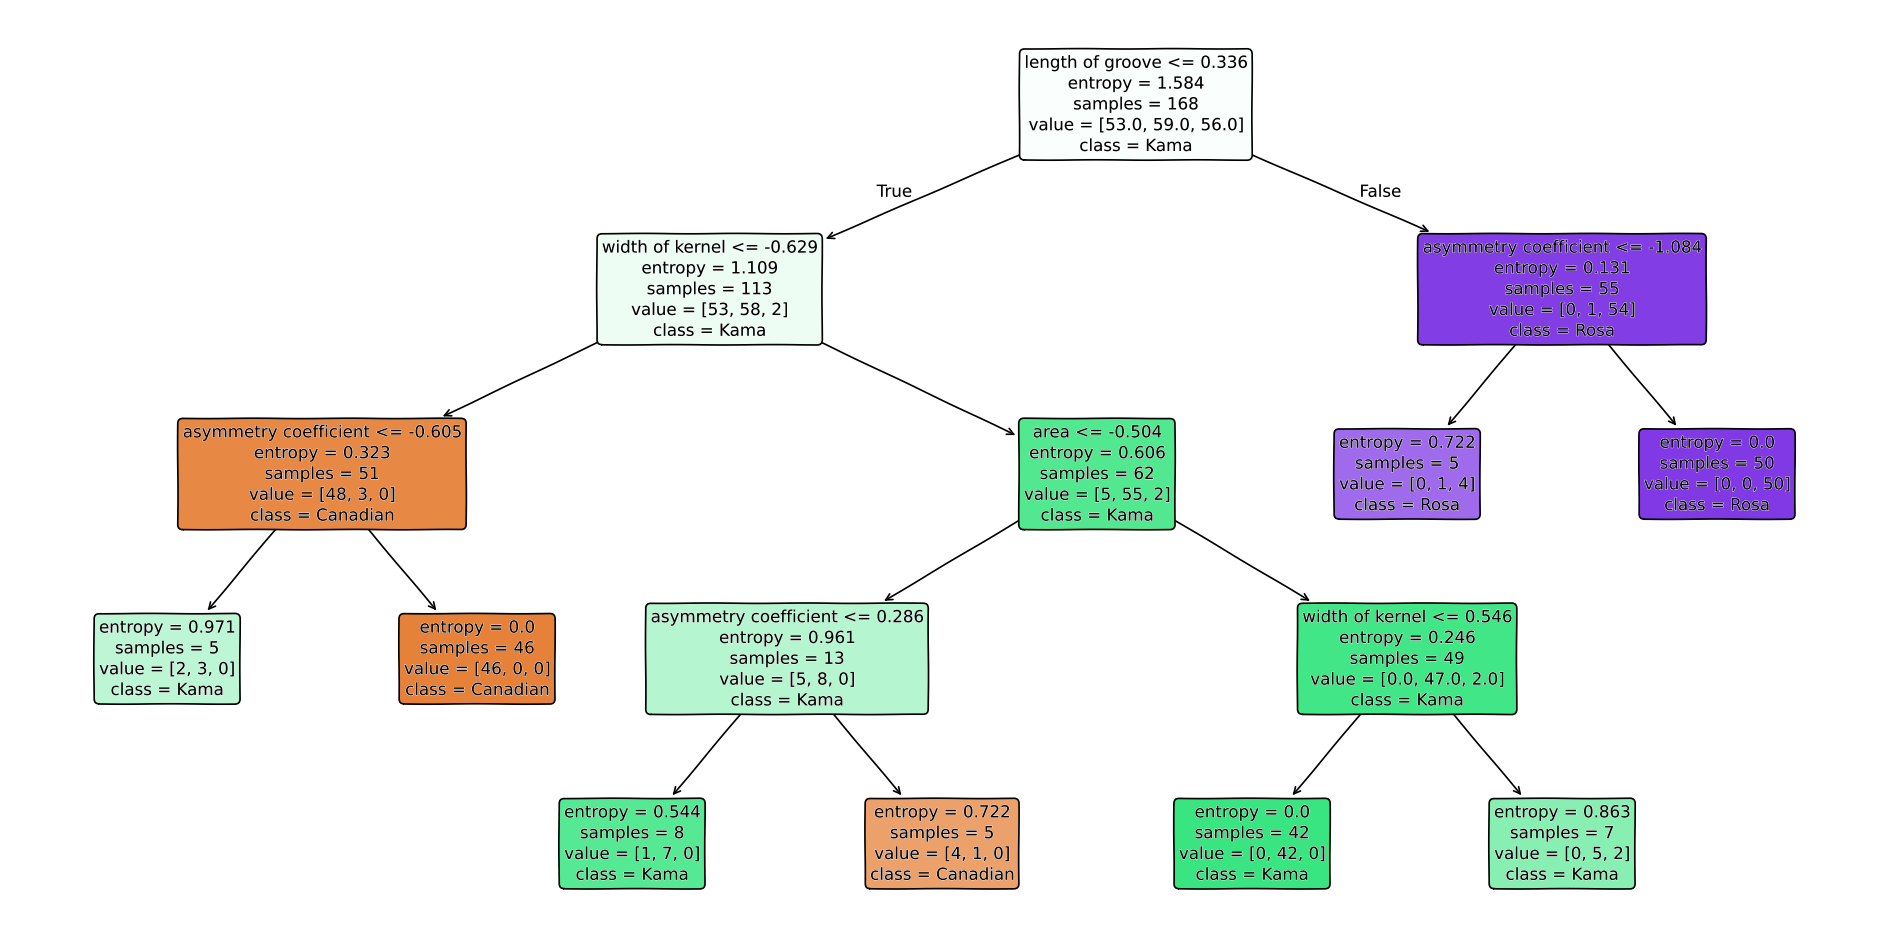

In [20]:
plt.figure(figsize=(20, 10), dpi=120)
plot_tree(
    dt_custom,
    feature_names=X.columns,
    class_names=np.unique(y).tolist(),
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.show()